<a href="https://colab.research.google.com/github/Esharma111/Bangalore_House_Prediction/blob/Bangalore-House-Prediction/GHI1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective:

Build an AI/ML model to forecast the day ahead solar ghi of a plant based
on the historical data like weather parameters from the plant's data.

In [757]:
# Import the librabies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [758]:
# Set seed for reproducibility

import os
import random

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [759]:
import warnings
warnings.filterwarnings("ignore")

In [760]:
DATA_DIR = "./"  # or "./data" if you store files in a folder
TRAIN_FILE = os.path.join(DATA_DIR, "Train Dataset.csv")
TEST_FILE = os.path.join(DATA_DIR, "Test Dataset.csv")

In [761]:
# Load Data

train_df = pd.read_csv(TRAIN_FILE)


In [762]:
# Load the dataset
train_df=pd.read_csv('/content/Train Dataset.csv')

In [763]:
train_df.shape

(2206, 23)

In [764]:
train_df.head(5)

,Unnamed: 0,timestamp,irradiance_global_reference,irradiance_horizontal,module_temperature_1,module_temperature_2,module_temperature_3,wind_direction,relative_humidity,horizontal_radiation_1,...,incident_radiation_2,incident_radiation_4,incident_radiation_3,reflected_radiation_1,reflected_radiation_2,reflected_radiation_4,reflected_radiation_3,ambient_temperature,wind_speed,ghi
0,0.0,10/1/2024 0:00,0.0,0.0,22.143874,21.766006,21.887832,166.493537,99.996814,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,23.450315,0.000000,0.0
1,1.0,10/1/2024 1:00,0.0,0.0,21.903667,21.491851,21.646608,257.272004,99.996272,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,23.215215,0.000000,0.0
2,2.0,10/1/2024 2:00,0.0,0.0,22.539134,22.290230,22.319763,212.567154,99.996691,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,23.301205,0.000000,0.0
3,3.0,10/1/2024 3:00,0.0,0.0,22.686070,22.513330,22.484921,157.928208,99.996403,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,23.352792,1.832727,0.0
4,4.0,10/1/2024 4:00,0.0,0.0,23.157860,22.858801,22.862068,142.271059,99.997145,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,23.505781,0.000000,0.0


In [765]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2206 entries, 0 to 2205
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   2182 non-null   float64
 1   timestamp                    2182 non-null   object 
 2   irradiance_global_reference  2182 non-null   float64
 3   irradiance_horizontal        2182 non-null   float64
 4   module_temperature_1         2166 non-null   float64
 5   module_temperature_2         2155 non-null   float64
 6   module_temperature_3         2150 non-null   float64
 7   wind_direction               2182 non-null   float64
 8   relative_humidity            2182 non-null   float64
 9   horizontal_radiation_1       2182 non-null   float64
 10  horizontal_radiation_2       9 non-null      float64
 11  horizontal_radiation_3       1331 non-null   float64
 12  incident_radiation_1         2182 non-null   float64
 13  incident_radiation

In [766]:
# Drop Unnamed column
train_df.drop(columns=['Unnamed: 0'], inplace=True)

In [767]:
# Convert timestamp to datetime object
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])

# Verify the change
print(train_df['timestamp'].dtype)

datetime64[ns]


In [768]:
# Check for missing values
missing_values = train_df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 timestamp                        24
irradiance_global_reference      24
irradiance_horizontal            24
module_temperature_1             40
module_temperature_2             51
module_temperature_3             56
wind_direction                   24
relative_humidity                24
horizontal_radiation_1           24
horizontal_radiation_2         2197
horizontal_radiation_3          875
incident_radiation_1             24
incident_radiation_2           1462
incident_radiation_4             51
incident_radiation_3            875
reflected_radiation_1            24
reflected_radiation_2          1461
reflected_radiation_4            51
reflected_radiation_3           875
ambient_temperature              24
wind_speed                       24
ghi                              24
dtype: int64


# Handling Missing Values


In [769]:
# Step 1: Drop rows with missing timestamp or target as these features can't be imputed by any numerical value
train_df = train_df.dropna(subset=['timestamp', 'ghi'])

In [770]:
train_df.isnull().sum()

,0
timestamp,0
irradiance_global_reference,0
irradiance_horizontal,0
module_temperature_1,16
module_temperature_2,27
module_temperature_3,32
wind_direction,0
relative_humidity,0
horizontal_radiation_1,0
horizontal_radiation_2,2173


 Missing data percentage for horizontal_radiation_2 : 98.5%
---> Action: Drop the column

Missing data percentage for incident_radiation_2:  65.2%
---> Action: Drop the column

Missing data percentage for reflected_radiation_2: 65.1%
---> Action: Drop the column

In [771]:
train_df.drop(columns=['horizontal_radiation_2', 'incident_radiation_2','reflected_radiation_2'], inplace=True)

Let's check the correlation among different readings of the radiations from various sensors.

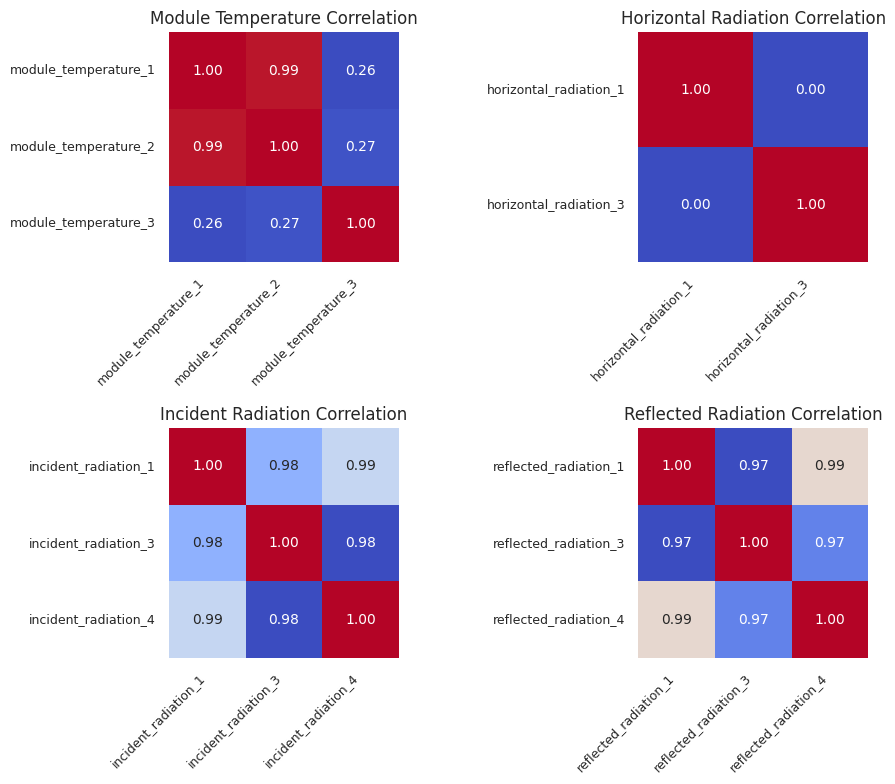

In [772]:
# Group columns
module_cols = ['module_temperature_1', 'module_temperature_2', 'module_temperature_3']
horizontal_cols = ['horizontal_radiation_1', 'horizontal_radiation_3']
incident_cols = ['incident_radiation_1', 'incident_radiation_3', 'incident_radiation_4']
reflected_cols = ['reflected_radiation_1', 'reflected_radiation_3', 'reflected_radiation_4']

# Setup subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2x2 layout
axes = axes.flatten()  # Flatten for easy iteration
sns.set(style="whitegrid", font_scale=1.0)

# Titles and groups
titles = ['Module Temperature Correlation',
          'Horizontal Radiation Correlation',
          'Incident Radiation Correlation',
          'Reflected Radiation Correlation']
groups = [module_cols, horizontal_cols, incident_cols, reflected_cols]

# Plot each group
for ax, cols, title in zip(axes, groups, titles):
    corr = train_df[cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True,
                ax=ax, cbar=False, annot_kws={"size": 10})
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


In [773]:
train_df.isnull().sum()

,0
timestamp,0
irradiance_global_reference,0
irradiance_horizontal,0
module_temperature_1,16
module_temperature_2,27
module_temperature_3,32
wind_direction,0
relative_humidity,0
horizontal_radiation_1,0
horizontal_radiation_3,851


# Final Imputation Strategy Based on Heatmaps & Missingness

1. Module Temperature Sensors

In [774]:
# Row-wise mean for module temperature
module_cols = ['module_temperature_1', 'module_temperature_2', 'module_temperature_3']
row_mean = train_df[module_cols].mean(axis=1, skipna=True)
for col in module_cols:
    train_df[col].fillna(row_mean, inplace=True)

2.  Horizontal Radiation

   Drop horizontal_radiation_3
  → It’s uncorrelated with horizontal_radiation_1 and over 38% missing — adds noise, not signal.

In [775]:
train_df.drop(columns=['horizontal_radiation_3'], inplace=True)

3. Incident Radiation

    Impute incident_radiation_3 and _4 using row-wise mean of the three

In [776]:
incident_cols = ['incident_radiation_1', 'incident_radiation_3', 'incident_radiation_4']
row_mean = train_df[incident_cols].mean(axis=1, skipna=True)
for col in ['incident_radiation_3', 'incident_radiation_4']:
    train_df[col].fillna(row_mean, inplace=True)

4. Reflected Radiation
  
    Impute reflected_radiation_3 and _4 using row-wise mean of the three

In [777]:
reflected_cols = ['reflected_radiation_1', 'reflected_radiation_3', 'reflected_radiation_4']
row_mean = train_df[reflected_cols].mean(axis=1, skipna=True)
for col in ['reflected_radiation_3', 'reflected_radiation_4']:
    train_df[col].fillna(row_mean, inplace=True)

In [778]:
train_df.isnull().sum()

,0
timestamp,0
irradiance_global_reference,0
irradiance_horizontal,0
module_temperature_1,16
module_temperature_2,16
module_temperature_3,16
wind_direction,0
relative_humidity,0
horizontal_radiation_1,0
incident_radiation_1,0


In [779]:
# Final step: fill remaining missing values in module temperature columns using column-wise median
for col in module_cols:
    train_df[col].fillna(train_df[col].median(), inplace=True)



In [780]:
train_df.isnull().sum()

,0
timestamp,0
irradiance_global_reference,0
irradiance_horizontal,0
module_temperature_1,0
module_temperature_2,0
module_temperature_3,0
wind_direction,0
relative_humidity,0
horizontal_radiation_1,0
incident_radiation_1,0


All missing values have been successfully handled

In [781]:
# Final Dataset shape
train_df.shape

(2182, 18)

#  Feature Engineering

In [782]:
# Useful time-based features from timestamp
train_df['hour'] = train_df['timestamp'].dt.hour
train_df['day'] = train_df['timestamp'].dt.day
train_df['month'] = train_df['timestamp'].dt.month
train_df['dayofweek'] = train_df['timestamp'].dt.dayofweek


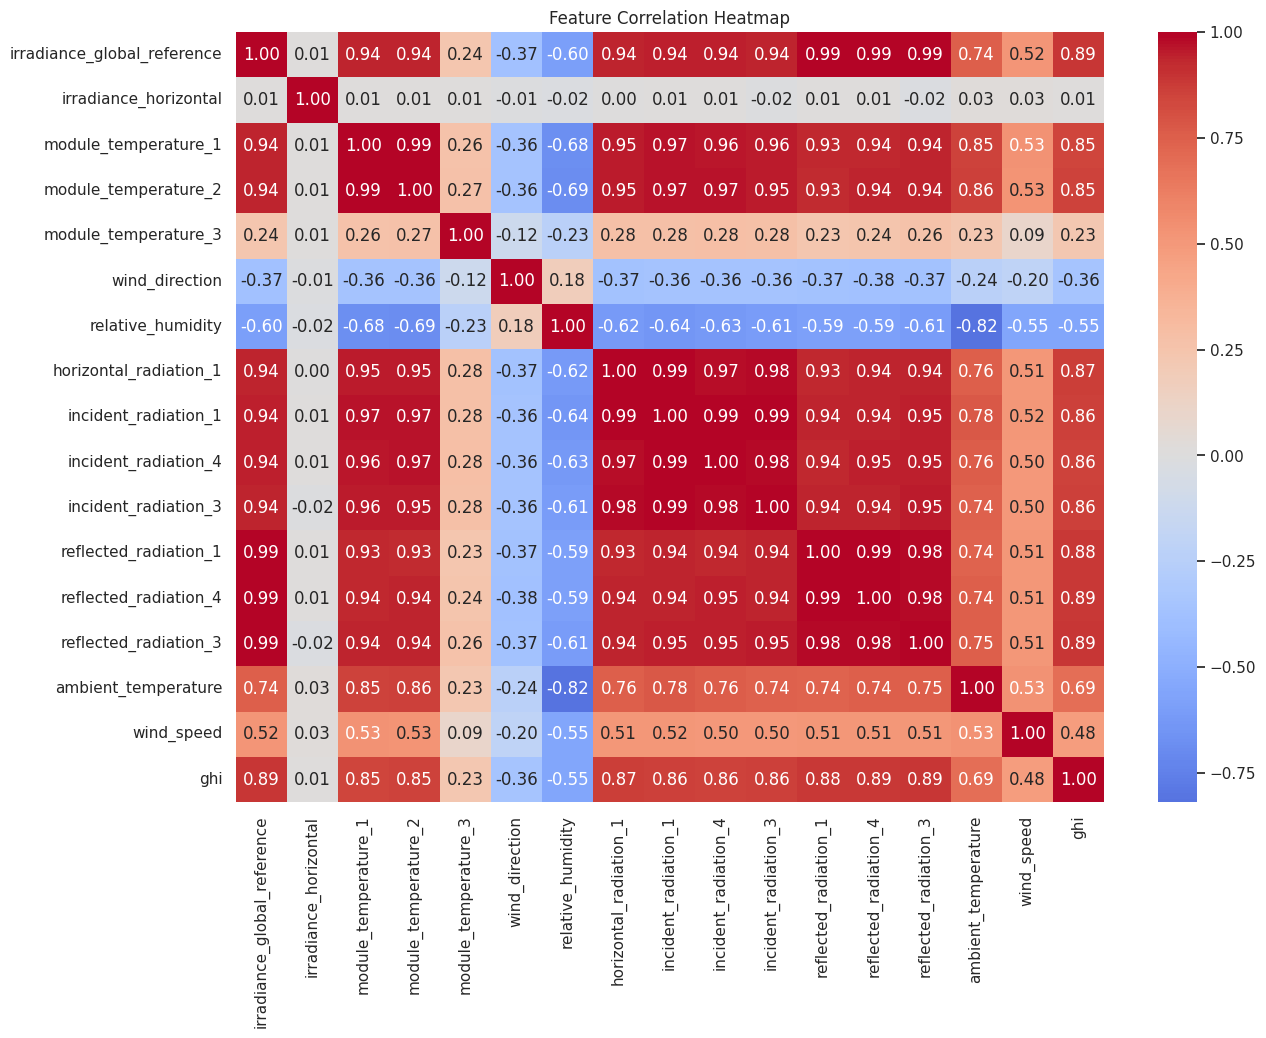

In [783]:
# Plot heatmap of feature correlations with 2 decimal places
plt.figure(figsize=(14, 10))
corr_matrix = train_df.drop(columns=['timestamp','hour','day','month','dayofweek']).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()


There are many fatures who are highly correlated.

Action:planning to use a tree-based model (like LightGBM/XGBoost), which:

  Handles multicollinearity internally by picking the most informative feature at each split.

  Doesn’t assume linear independence between predictors (unlike linear regression).

  Automatically ignores less useful features (even if they’re correlated).

# Outliers Detection


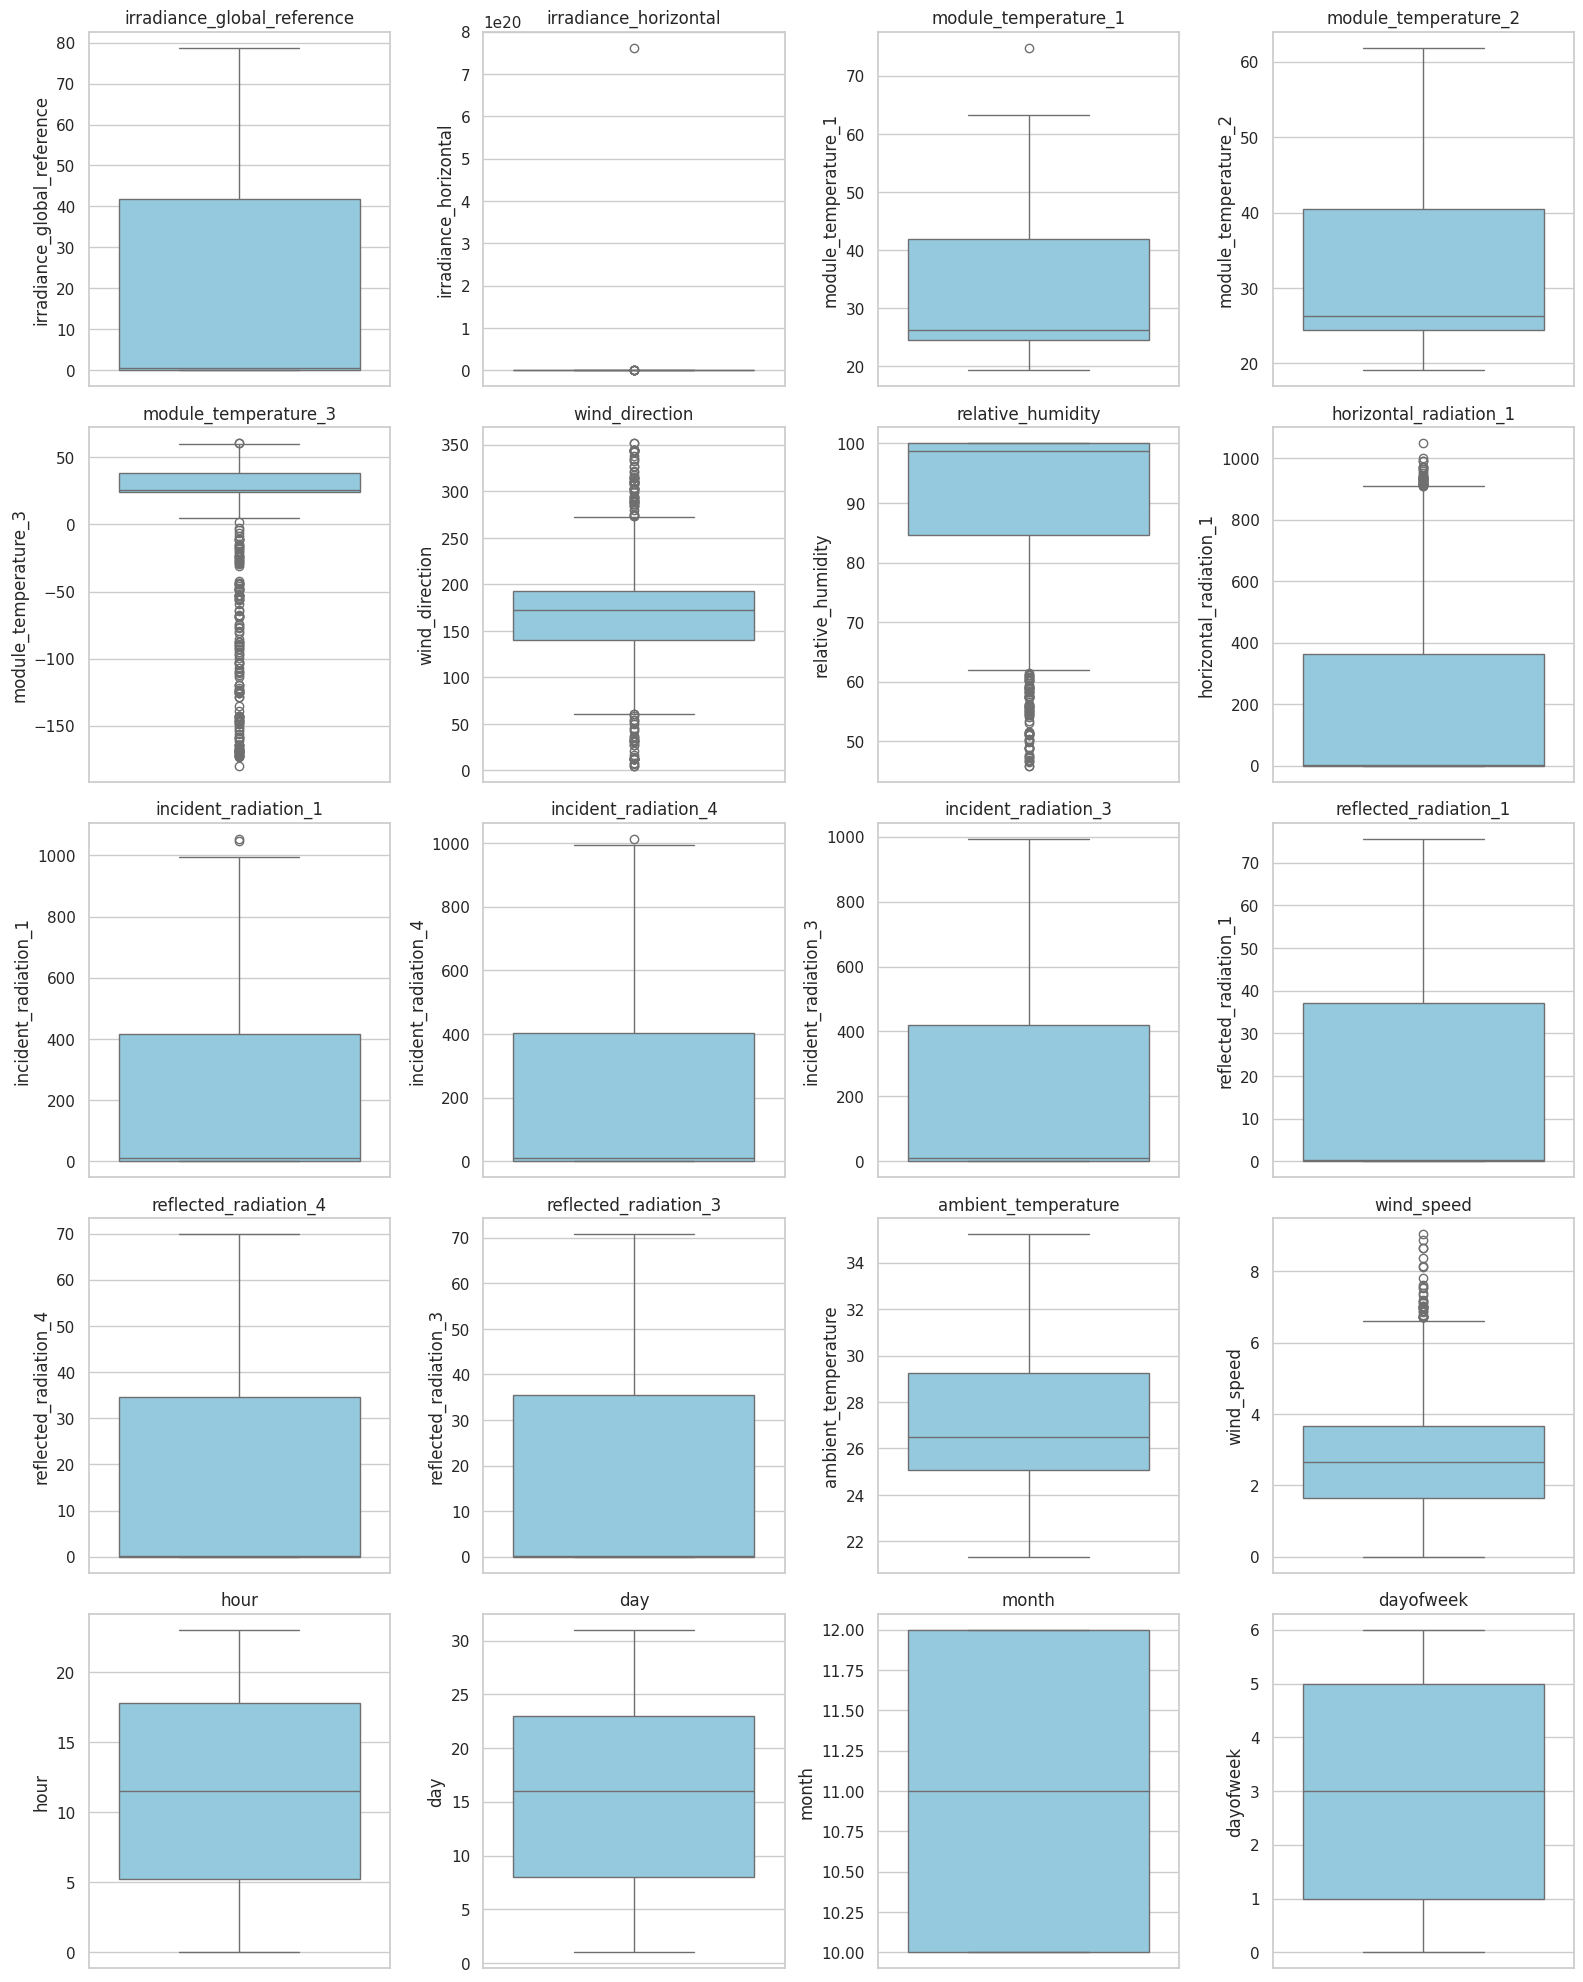

In [784]:
numeric_cols = train_df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('ghi')  # skip target for now

# Calculate the number of rows and columns needed for subplots
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4  # Calculate rows needed, assuming max 4 columns per row

plt.figure(figsize=(16, n_rows * 4)) # Adjust figure size based on number of rows
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 4, i) # Use calculated rows and 4 columns
    sns.boxplot(y=train_df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

Observations per Feature:

Outliers are found in the following features:

1. irradiance_horizontal:
    One giant outlier (e+20). Action needed.

2. module_temperature_3
   Negative values (< 0°C) down to -150°C are not realistic.

  In reality, module temperatures rarely fall below -40°C, even in extreme climates. Action needed.

3.  wind_direction
    These are not outliers as wind direction range lies from 0° to 360°.

4.  relative_humidity
    Valid range: 0% to 100%. Hence these are not outliers too.
  
5. horizontal_radiation_1
    A few high values (>950) — possibly sunny noon hours.

    These are expected and valid in clear-sky conditions.

In [785]:
## Outliers treatment for irradiance_horizontal

# Define a safe upper bound (e.g., 1500 W/m² for irradiance)
irr_col = 'irradiance_horizontal'

# Set extreme values to NaN
train_df.loc[train_df[irr_col] > 1000, irr_col] = np.nan

# Fill with median
train_df[irr_col].fillna(train_df[irr_col].median(), inplace=True)


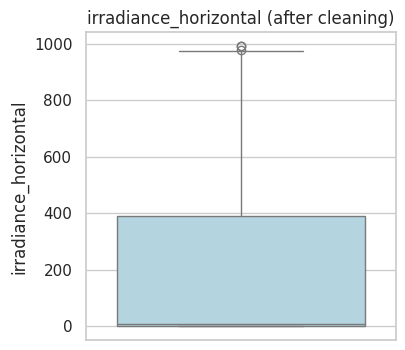

In [786]:
# Recheck the boxplot after fixing
plt.figure(figsize=(4, 4))
sns.boxplot(y=train_df['irradiance_horizontal'], color='lightblue')
plt.title('irradiance_horizontal (after cleaning)')
plt.show()

A few values slightly above 1000 W/m² are visible, but these are realistic for clear sunny midday conditions.

In [787]:
# Outliers treatment for module_temperature_3

train_df['module_temperature_3'] = train_df['module_temperature_3'].apply(lambda x: np.nan if x < -40 or x > 90 else x)
train_df['module_temperature_3'].fillna(train_df['module_temperature_3'].median(), inplace=True)


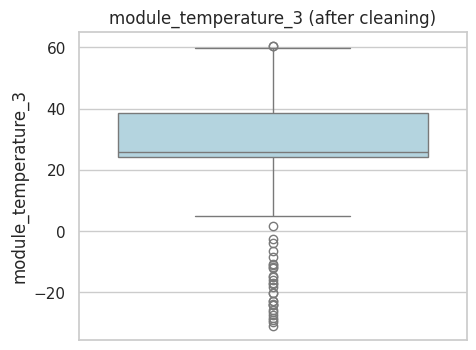

In [788]:
# Recheck the boxplot after fixing

plt.figure(figsize=(5, 4))
sns.boxplot(y=train_df['module_temperature_3'], color='lightblue')
plt.title('module_temperature_3 (after cleaning)')
plt.show()

Current lowest values are around -20°C to 0°C, which are possible in cold climates

# Univariate Analysis:

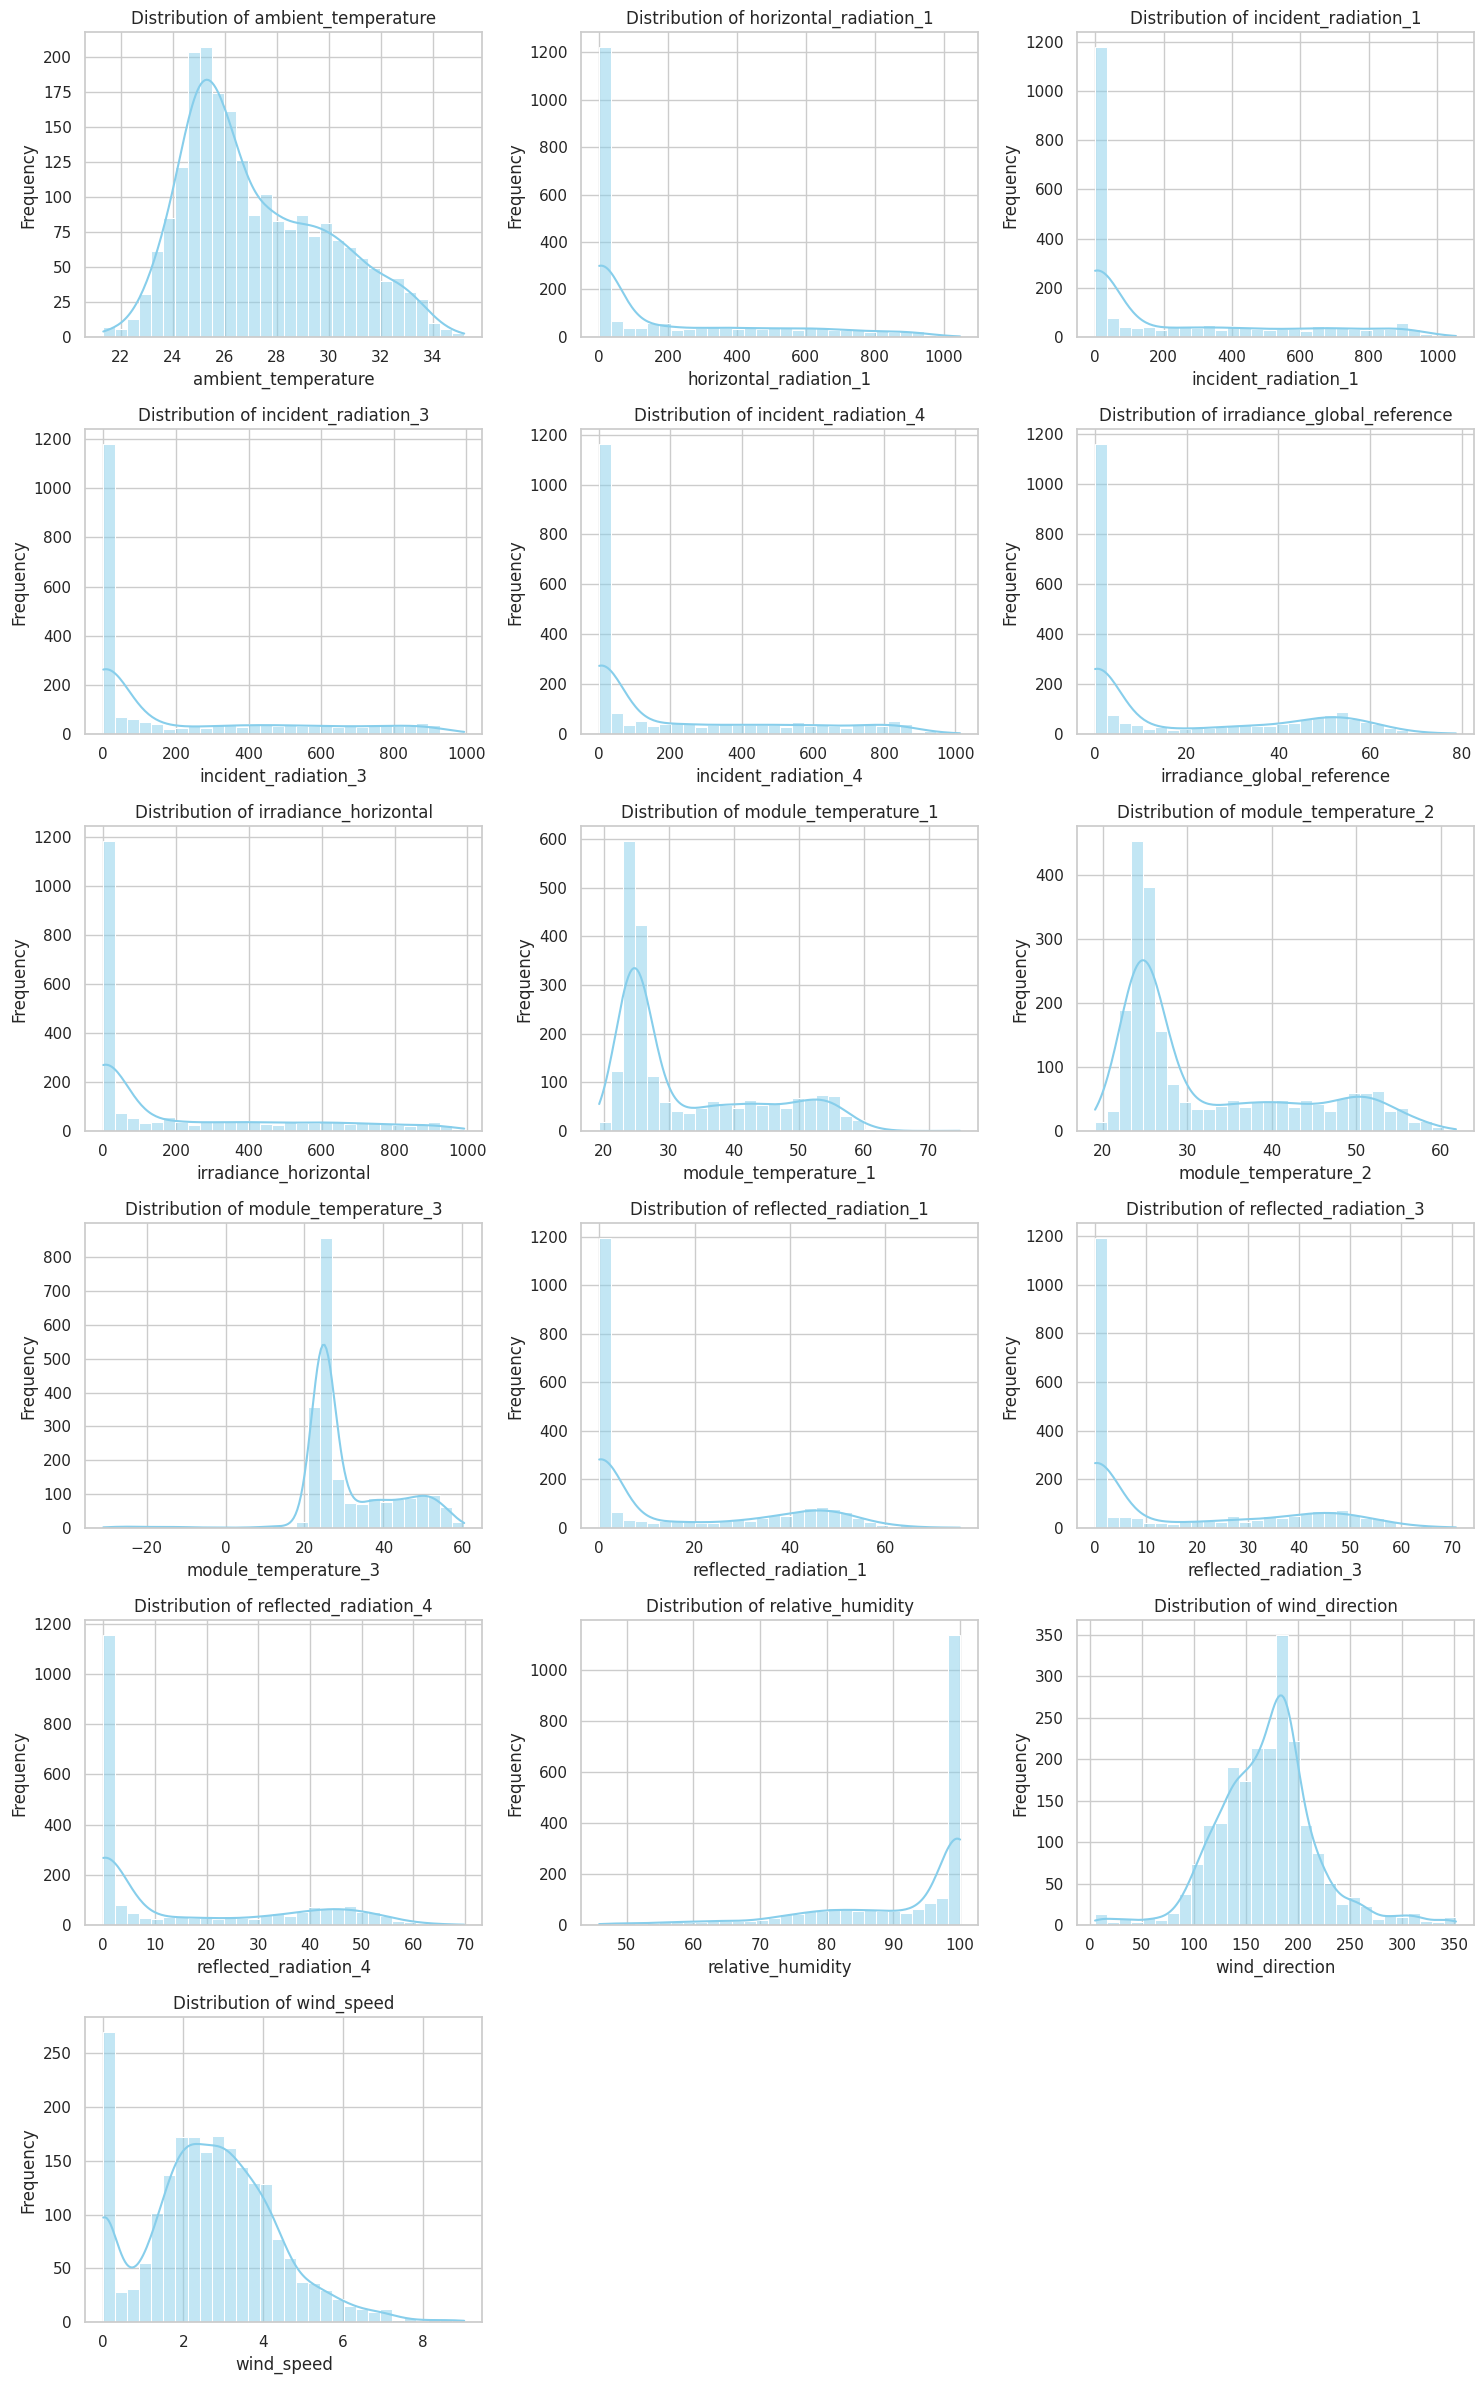

In [789]:
# Exclude time-based features and 'ghi'
excluded_cols = ['ghi', 'hour', 'day', 'month', 'dayofweek']
numeric_cols = train_df.select_dtypes(include='number').columns.difference(excluded_cols).tolist()

# Subplot settings
num_features = len(numeric_cols)
cols = 3
rows = (num_features + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

# Plot histograms with KDE
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(train_df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


 Summary of Feature Insights (Univariate Analysis)

 | Feature Group                                                                                                                              | Skewness                          | Insight                                                                  |
| ------------------------------------------------------------------------------------------------------------------------------------------ | --------------------------------- | ------------------------------------------------------------------------ |
| **Temperatures** (`module_temperature_1/2/3`, `ambient_temperature`)                                                                       | Slightly right or bimodal         | Captures day vs. night variation; useful for modeling sunlight exposure. |
| **Radiation & Irradiance** (`incident_*`, `reflected_*`, `horizontal_radiation_1`, `irradiance_horizontal`, `irradiance_global_reference`) | Strong right skew                 | Most values are near 0 (nighttime); valid pattern for solar data.        |
| **Relative Humidity**                                                                                                                      | Left skewed                       | Mostly high humidity values; stable readings, may have moderate impact.  |
| **Wind Speed**                                                                                                                             | Right skewed                      | Many low-speed values; could help capture weather-related variability.   |
| **Wind Direction**                                                                                                                         | Roughly normal (centered at 180°) | Appears stable; may help when combined with other weather features.      |


# Bivariate Analysis
— seeing how these features relate to ghi (target variable).

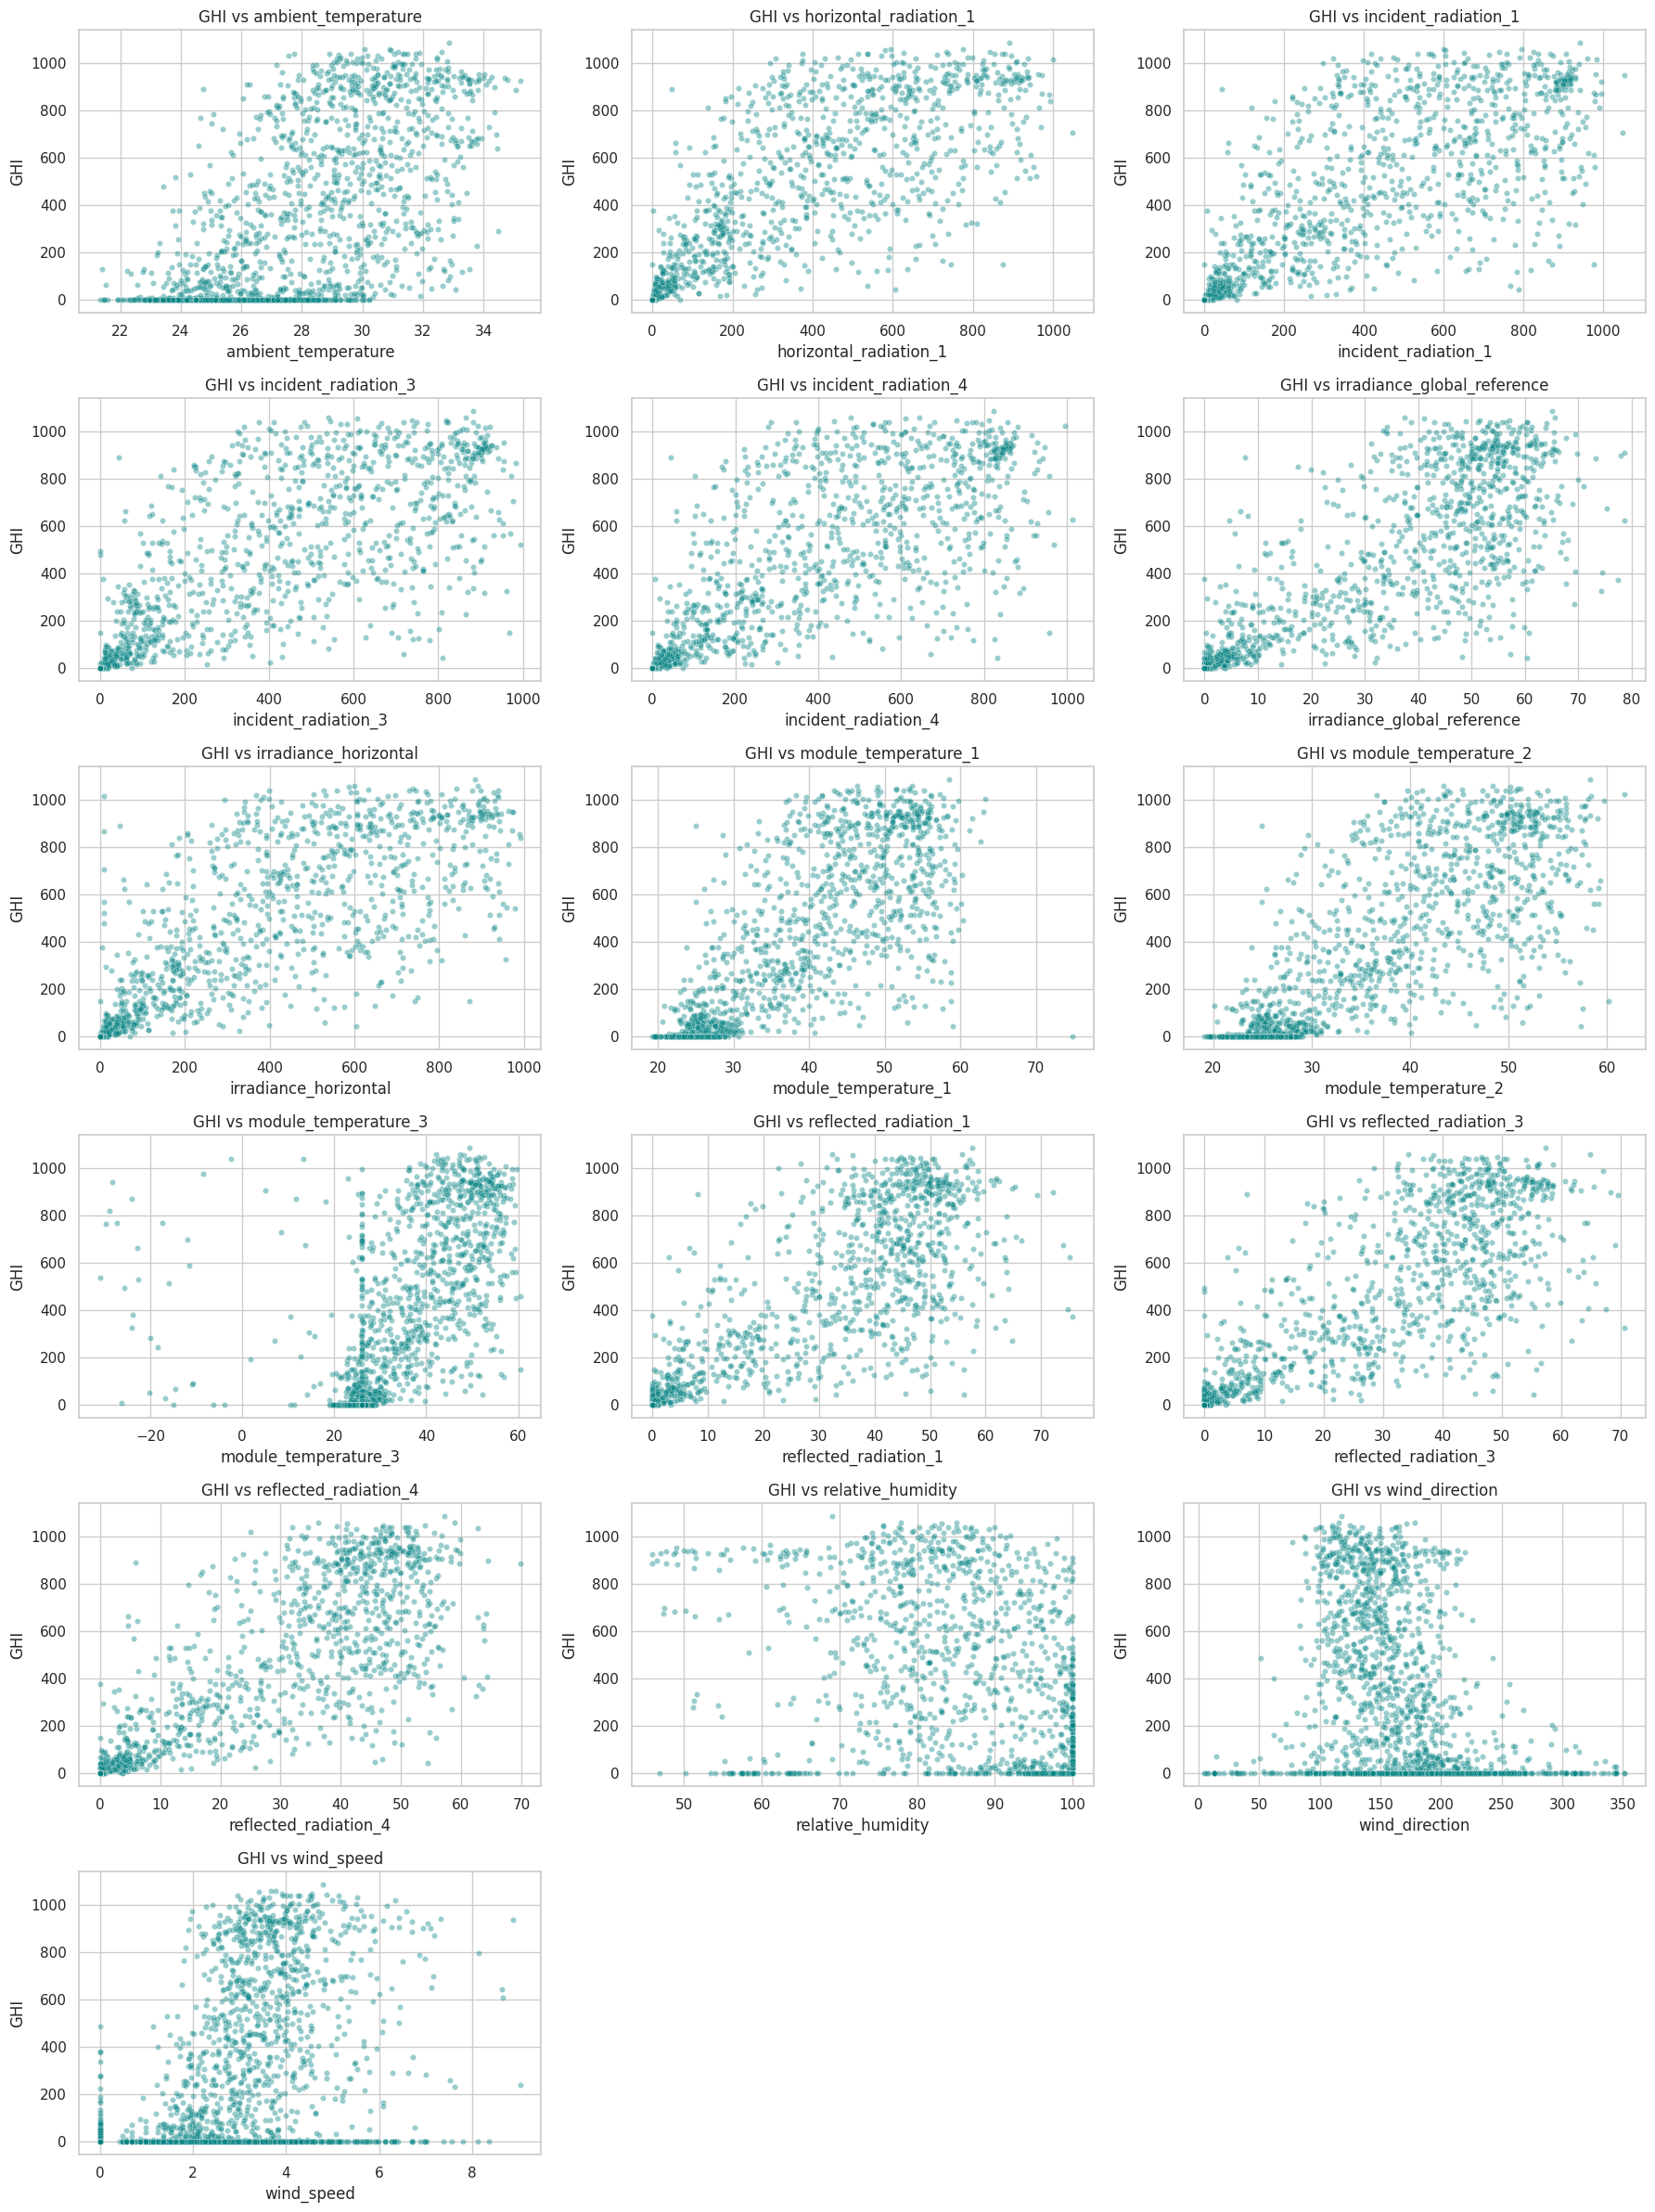

In [790]:
# Features to plot against GHI (exclude time features + target)
excluded_cols = ['ghi', 'hour', 'day', 'month', 'dayofweek']
numeric_cols = train_df.select_dtypes(include='number').columns.difference(excluded_cols).tolist()

# Plotting
cols = 3
rows = (len(numeric_cols) + cols - 1) // cols
plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.scatterplot(x=train_df[col], y=train_df['ghi'], alpha=0.4, s=20, color='teal')
    plt.title(f'GHI vs {col}')
    plt.xlabel(col)
    plt.ylabel('GHI')
    plt.grid(True)

plt.tight_layout()
plt.show()


# Hourly & Weekly Trend of GHI (Grouped Stats)
 - To see if there's a clear pattern by hour or month.


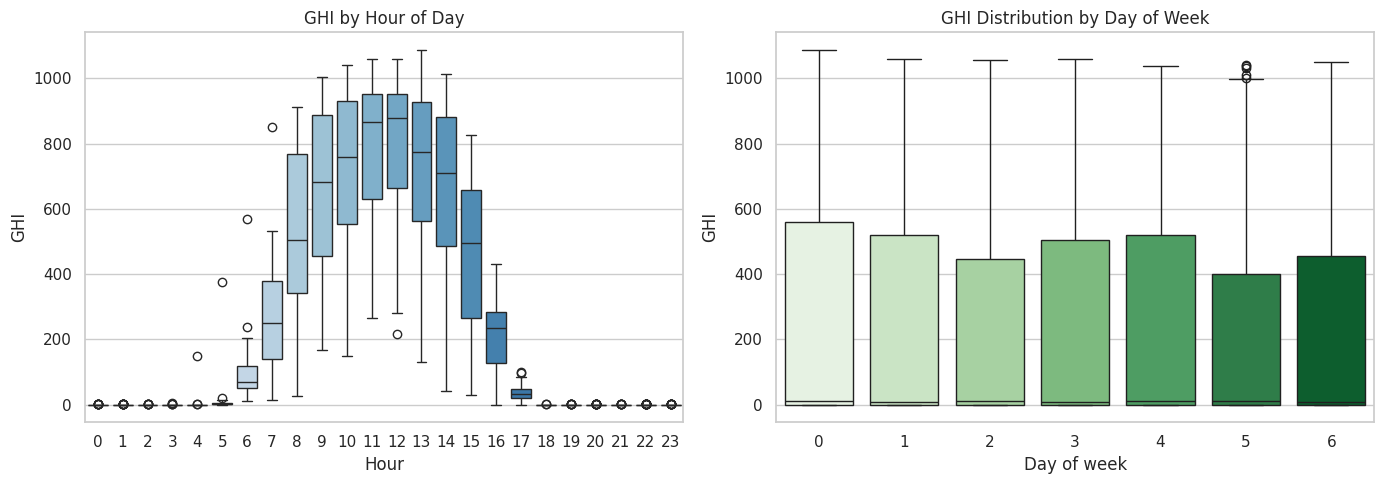

In [791]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly GHI distribution
sns.boxplot(x='hour', y='ghi', data=train_df, ax=axes[0], palette='Blues')
axes[0].set_title('GHI by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('GHI')

# GHI Distribution by Day of Week
sns.boxplot(x='dayofweek', y='ghi', data=train_df, ax=axes[1], palette='Greens')
axes[1].set_title('GHI Distribution by Day of Week')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('GHI')

plt.tight_layout()
plt.show()


| Feature       | Distribution Pattern                            | Insight                                                                |
| ------------- | ----------------------------------------------- | ---------------------------------------------------------------------- |
| **hour**      | Bell-shaped curve peaking between 10 AM to 2 PM | GHI follows a strong daily cycle: zero at night, rising during the day |
| **dayofweek** | Flat, minor fluctuations across all 7 days      | No consistent pattern; GHI doesn’t depend on day of the week           |


# Feature Importance Using Random Forest

In [792]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [793]:
# Step 1: Prepare Features & Target

excluded_cols = ['ghi', 'timestamp']
X = train_df.drop(columns=excluded_cols)
y = train_df['ghi']

In [794]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [795]:
# Step 2: Train Random Forest

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

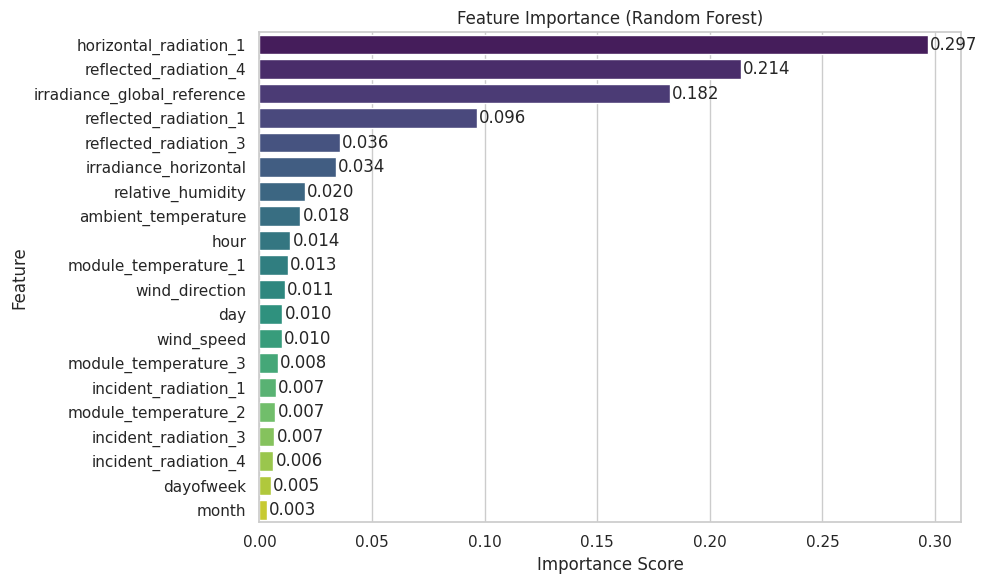

In [796]:
# Step 3: Plot Feature Importance with Annotations

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")

# Add score annotations to each bar
for i, (feature, importance) in enumerate(importances.items()):
    plt.text(importance + 0.001, i, f"{importance:.3f}", va='center')

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Features like incident_radiation_1, incident_radiation_3, incident_radiation_4, module_temperature_2, and module_temperature_3 showed very low importance scores below 0.01, indicating minimal contribution to GHI prediction.

Time-based features such as day (0.010), dayofweek (0.005), and month (0.003) also had low importance, confirming they are not very predictive and can be dropped.

# Train RandomForest and Evaluate with MAPE

In [797]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

In [798]:
# Finalize Feature Set

low_importance_features = [
    'incident_radiation_1', 'incident_radiation_3', 'incident_radiation_4',
    'module_temperature_2', 'module_temperature_3',
    'month', 'day', 'dayofweek','wind_speed'
]

excluded_cols = ['ghi', 'timestamp'] + low_importance_features
X = train_df.drop(columns=excluded_cols, errors='ignore')
y = train_df['ghi']

# Binary Classifier target
y_class = (y > 0).astype(int)  # 1 = daylight, 0 = night/zero GHI

In [799]:
# Train-test split for classification
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [800]:
# # # Define classifier parameter grid
# # clf_param_grid = {
# #     'n_estimators': [100, 200],
# #     'max_depth': [10, 20, None],
# #     'min_samples_split': [2, 5],
# #     'min_samples_leaf': [1, 2],
# #     'max_features': ['sqrt', 'auto']
# # }

# # # Base classifier
# # rf_clf = RandomForestClassifier(random_state=42)

# # # Grid Search for classifier
# # clf_grid_search = GridSearchCV(
# #     estimator=rf_clf,
# #     param_grid=clf_param_grid,
# #     cv=3,
# #     scoring='accuracy',
# #     verbose=2,
# #     n_jobs=-1
# # )

# # # Fit classifier tuning
#  clf_grid_search.fit(X_train_c, y_train_c)

# # Use best classifier
# # best_clf = clf_grid_search.best_estimator_
# # print("Best Classifier Params:\n", clf_grid_search.best_params_)

In [801]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)

# Predict classifier labels on validation set
y_bin_pred = clf.predict(X_val_c)

In [802]:
# !pip install xgboost

In [803]:
# from xgboost import XGBClassifier

# xgb_clf = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     random_state=42,
#     use_label_encoder=False,
#     eval_metric='logloss'
# )

# xgb_clf.fit(X_train_c, y_train_c)


In [804]:
# # # Predict probabilities
# y_proba = clf.fit.predict_proba(X_val_c)[:, 1]  # probability of class 1

# # # Make threshold harder (favor class 0)
# y_class_pred = (y_proba > 0.7).astype(int)


In [805]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_val_c, y_bin_pred, target_names=["GHI=0", "GHI>0"]))

Classification Report:

              precision    recall  f1-score   support

       GHI=0       0.93      0.98      0.96       186
       GHI>0       0.99      0.94      0.97       251

    accuracy                           0.96       437
   macro avg       0.96      0.96      0.96       437
weighted avg       0.96      0.96      0.96       437



In [806]:
# Filter only GHI > 0 for regression
regression_mask = y > 0
X_reg = X[regression_mask]
y_reg = y[regression_mask]

In [807]:
# Train-test split for regression
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [808]:



# GridSearchCV for tuning RandomForestRegressor
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'auto']
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error',
    verbose=2,
    n_jobs=-1
)

In [809]:
# Fit Grid Search
grid_search.fit(X_train_r, y_train_r)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'auto'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_percentage_error', verbose=2)

In [810]:
# Best Regressor
best_reg = grid_search.best_estimator_
print("Best Parameters for Regression:\n", grid_search.best_params_)

Best Parameters for Regression:
 {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [811]:
# Step 4: Predict Combined Outputs
# ------------------------------
# Create validation set from full data again
X_all_train, X_val, y_all_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [812]:
# Predict classifier labels on validation set
y_bin_pred = clf.predict(X_val)

In [813]:
# Predict regression values
y_reg_pred = best_reg.predict(X_val)

In [814]:
# Final prediction
y_final_pred = np.where(y_bin_pred == 0, 0, y_reg_pred)


In [815]:
# Step 5: Safe MAPE Function
# ------------------------------
def safe_mape_all(y_true, y_pred, epsilon=0.1):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = np.maximum(np.abs(y_true), epsilon)
    return np.mean(np.abs((y_true - y_pred) / denominator)) * 100

In [816]:
# Step 6: Evaluation
# ------------------------------
mape = safe_mape_all(y_val, y_final_pred)
print(f"Final Two-Stage Model MAPE (with GridSearch): {mape:.2f}%")

Final Two-Stage Model MAPE (with GridSearch): 71.87%
